# Train XGBoost model (t+3 target)
Train an XGBoost classifier on `data/processed/xgboost_t3`, using `target_t+3` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Hyperparameters are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve against the business objective.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_xgboost
from train_xgboost import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t3"
train_xgboost.set_horizon(HORIZON)
TARGET_COLUMN = train_xgboost.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset xgboost_t3 with target 'target_t+3'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,664
Validation observations: 3,728
Number of features: 30

Class distribution in training data:
  Negative: 17,317
  Positive: 1,347
  scale_pos_weight: 12.86


Best trial: 25. Best value: 0.152292: 100%|██████████| 50/50 [00:15<00:00,  3.21it/s]



Best validation PR-AUC: 0.1523
Best hyperparameters:
  learning_rate: 0.05
  max_depth: 4
  min_child_weight: 5
  subsample: 0.85
  colsample_bytree: 1.0
  gamma: 0
  reg_alpha: 0.1
  reg_lambda: 50
  scale_pos_weight: 12.855976243504083


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,state
25,25,0.152292,2026-08-31 10:37:36.196071,2026-08-31 10:37:36.494000,0 days 00:00:00.297929,1.00,0.0,0.05,4,5,0.1,50,0.85,COMPLETE
26,26,0.152292,2026-08-31 10:37:36.498084,2026-08-31 10:37:36.786976,0 days 00:00:00.288892,1.00,0.0,0.05,4,5,0.1,50,0.85,COMPLETE
44,44,0.151113,2026-08-31 10:37:42.290568,2026-08-31 10:37:42.632282,0 days 00:00:00.341714,0.85,1.0,0.03,4,5,0.0,1,1.00,COMPLETE
43,43,0.151113,2026-08-31 10:37:41.943816,2026-08-31 10:37:42.289565,0 days 00:00:00.345749,0.85,1.0,0.03,4,5,0.0,1,1.00,COMPLETE
42,42,0.151113,2026-08-31 10:37:41.595866,2026-08-31 10:37:41.940317,0 days 00:00:00.344451,0.85,1.0,0.03,4,5,0.0,1,1.00,COMPLETE
41,41,0.151113,2026-08-31 10:37:41.238217,2026-08-31 10:37:41.593775,0 days 00:00:00.355558,0.85,1.0,0.03,4,5,0.0,1,1.00,COMPLETE
40,40,0.151113,2026-08-31 10:37:40.862677,2026-08-31 10:37:41.236214,0 days 00:00:00.373537,0.85,1.0,0.03,4,5,0.0,1,1.00,COMPLETE
37,37,0.150865,2026-08-31 10:37:40.083855,2026-08-31 10:37:40.359738,0 days 00:00:00.275883,0.70,1.0,0.03,4,5,0.0,50,1.00,COMPLETE
36,36,0.150865,2026-08-31 10:37:39.803002,2026-08-31 10:37:40.081846,0 days 00:00:00.278844,0.70,1.0,0.03,4,5,0.0,50,1.00,COMPLETE
34,34,0.150865,2026-08-31 10:37:39.380413,2026-08-31 10:37:39.662637,0 days 00:00:00.282224,0.70,1.0,0.03,4,5,0.0,50,1.00,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

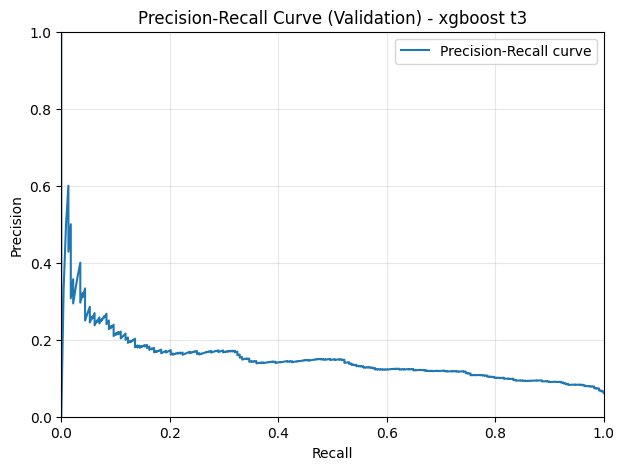

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - xgboost {HORIZON}",
)

In [6]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.4].head(20)

,threshold,precision,recall
3599,0.753598,0.400000,0.035088
3611,0.762329,0.500000,0.017544
3610,0.762297,0.444444,0.017544
3609,0.762260,0.400000,0.017544
3612,0.763327,0.428571,0.013158
3613,0.763957,0.500000,0.013158
3614,0.764664,0.600000,0.013158
3615,0.764976,0.500000,0.008772


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

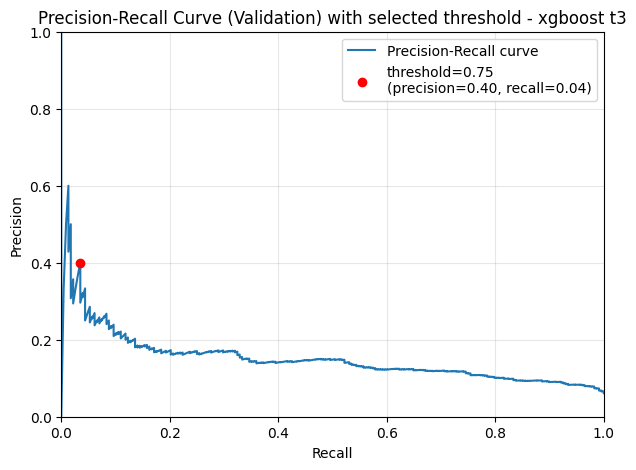

In [7]:
SELECTED_THRESHOLD = 0.753598

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - xgboost {HORIZON}",
);

## Final evaluation

In [8]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.190444,0.450000,0.006682,0.013168,0.344444,0.023014
val,0.152292,0.400000,0.035088,0.064516,0.233333,0.092105
test,0.155504,0.318182,0.025641,0.047458,0.211111,0.069597


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [9]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\xgboost_t3.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/xgboost_t3.joblib')